# Caractérisation du jeu de données

Ce notebook produit les figures descriptives utilisées pour caractériser les données.

> **Style publication ML.** Les visualisations suivent une grammaire graphique homogène inspirée des figures de publications en machine learning : hiérarchie visuelle minimale, typographie compacte, grands canevas, axes explicitement nommés et annotations quantitatives intégrées. La palette est limitée aux trois couleurs du projet — **Brown `#ad4d03`**, **Green `#509679`**, **Blue `#0062ad`** — avec leurs variations obtenues par transparence (`alpha`).

Les figures sont exportées en haute résolution PDF, avec un padding externe uniforme afin d'éviter que les titres, labels, légendes ou annotations soient coupés.


**Mise à jour :** les titres, sous-titres, axes, annotations et libellés de partitions sont en français. Les identifiants techniques des stratégies (S1–S8) sont conservés tels quels.

Les PDF utilisent désormais, figure par figure, le même ratio largeur/hauteur que les images affichées dans le notebook original, afin d'éviter toute déformation ou changement de composition.


## 1. Configuration

In [28]:
from pathlib import Path
import json
import re
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd

# Chemins des fichiers
SCENARIOS_PATH = "data/scenarios_merged.jsonl"
SFT_TRAIN_PATH = "data/sft_train.jsonl"
SFT_EXECUTION_PATH = "data/sft_execution_data.jsonl"
ENRICHED_SFT_PATH = "data/enriched_sft_train.jsonl"
GRPO_TRAIN_PATH = "data/grpo_train.jsonl"
VAL_PATH = "data/val.jsonl"
TEST_PATH = "data/test.jsonl"

FIGURES_DIR = "figures/"
FIGURES_PATH = Path(FIGURES_DIR)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

# ============================================================
# Palette utilisateur — publication ML
# ============================================================
BROWN = "#ad4d03"
GREEN = "#509679"
BLUE = "#0062ad"

# Variations obtenues par transparence : pas de nouvelles couleurs arbitraires.
BROWN_A = (0.678, 0.302, 0.012, 0.18)
GREEN_A = (0.314, 0.588, 0.475, 0.18)
BLUE_A = (0.000, 0.384, 0.678, 0.18)

BROWN_M = (0.678, 0.302, 0.012, 0.45)
GREEN_M = (0.314, 0.588, 0.475, 0.45)
BLUE_M = (0.000, 0.384, 0.678, 0.45)

BROWN_S = (0.678, 0.302, 0.012, 0.70)
GREEN_S = (0.314, 0.588, 0.475, 0.70)
BLUE_S = (0.000, 0.384, 0.678, 0.70)

DARK = "#24313A"
GREY = "#69757D"
GRID = "#D9E0E4"
LIGHT_GREY = "#EEF2F4"

# Style proche d'une figure de publication ML :
# canevas large, typographie compacte, peu d'éléments décoratifs.
# Chaque figure conserve le ratio largeur/hauteur de son image d'origine dans le notebook.
plt.rcParams.update({
    "figure.figsize": (11.5, 6.8),
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "font.size": 10.5,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 10.5,
    "axes.labelweight": "normal",
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9.5,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "#BFC9CE",
    "axes.labelcolor": DARK,
    "xtick.color": DARK,
    "ytick.color": DARK,
    "text.color": DARK,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def style_ax(ax, grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#BFC9CE")
    ax.spines["bottom"].set_color("#BFC9CE")
    ax.grid(
        axis=grid_axis,
        color=GRID,
        linewidth=0.65,
        alpha=0.72,
        linestyle="-"
    )
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", which="major", length=3.5, width=0.7, pad=4)

def add_header(fig, title, subtitle=None):
    # Titre aligné dans la même zone que le contenu.
    fig.text(
        0.085, 0.955, title,
        ha="left", va="top",
        fontsize=15, fontweight="bold",
        color=DARK
    )
    if subtitle:
        fig.text(
            0.085, 0.915, subtitle,
            ha="left", va="top",
            fontsize=9.5, color=GREY
        )

def finish_figure(fig, filename):
    # Padding uniforme explicite : 0.085 autour du contenu.
    fig.subplots_adjust(
        left=0.085, right=0.915,
        bottom=0.105, top=0.825
    )
    path = FIGURES_PATH / filename
    fig.savefig(
        path,
        bbox_inches=None,
        pad_inches=0.0,
        facecolor="white"
    )
    print(f"Figure sauvegardée : {path}")
    return path


## 2. Fonctions utilitaires

In [29]:
CONFLICT_ORDER = ["IC", "CM", "IM", "IC+CM", "IC+IM", "CM+IM", "IC+CM+IM", "sans conflit"]
STRATEGY_ORDER = [f"S{i}" for i in range(1, 9)]

def read_jsonl(path):
    path = Path(path)
    records = []
    with path.open("r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

def normalize_conflict_category(record):
    if record.get("conflict_category"):
        return str(record["conflict_category"]).replace(
            "CM+IC", "IC+CM"
        ).replace(
            "IC+IM+CM", "IC+CM+IM"
        ).replace(
            "CM+IC+IM", "IC+CM+IM"
        )
    conflicts = record.get("conflicts", []) or []
    conflict_types = sorted({
        str(conflict.get("type"))
        for conflict in conflicts
        if isinstance(conflict, dict) and conflict.get("type")
    })
    return "+".join(conflict_types) if conflict_types else "sans conflit"

def extract_json_object(text):
    if not isinstance(text, str):
        return None
    cleaned = re.sub(r"```json\s*|```\s*", "", text).strip()
    match = re.search(r"\{.*\}", cleaned, flags=re.DOTALL)
    if not match:
        return None
    try:
        parsed = json.loads(match.group())
    except json.JSONDecodeError:
        return None
    return parsed if isinstance(parsed, dict) else None

def extract_strategy_from_messages(record):
    messages = record.get("messages") or []
    if not messages:
        return None
    assistant_content = messages[-1].get("content", "") if isinstance(messages[-1], dict) else ""
    parsed = extract_json_object(assistant_content)
    if parsed and parsed.get("strategy"):
        match = re.search(r"S[1-8]", str(parsed["strategy"]))
        return match.group(0) if match else None
    match = re.search(r"\b(S[1-8])\b", assistant_content)
    return match.group(1) if match else None

def strategy_list(record):
    if "valid_strategies" in record and isinstance(record["valid_strategies"], list):
        return [item for item in record["valid_strategies"] if item in STRATEGY_ORDER]
    strategy = extract_strategy_from_messages(record)
    return [strategy] if strategy else []

def scenario_id(record, index):
    return str(record.get("query_id") or record.get("query") or index)

def iter_source_elements(record):
    for conflict in record.get("conflicts", []) or []:
        if not isinstance(conflict, dict):
            continue
        for element in conflict.get("conflictual_element", []) or []:
            if isinstance(element, dict):
                yield element
    for element in record.get("non_conflictual_elements", []) or []:
        if isinstance(element, dict):
            yield element

def count_retrieved_documents(record):
    if isinstance(record.get("documents"), list):
        return len(record["documents"])
    seen = set()
    for element in iter_source_elements(record):
        if element.get("source_type") == "parametric" or element.get("source_corpus") == "parametric":
            continue
        key = str(element.get("document_id") or element.get("id") or element.get("title") or "")
        if key:
            seen.add(key)
    return len(seen)


## 3. Chargement des données

In [30]:
scenarios = read_jsonl(SCENARIOS_PATH)
sft_train = read_jsonl(SFT_TRAIN_PATH)
sft_execution_data = read_jsonl(SFT_EXECUTION_PATH)
enriched_sft_train = read_jsonl(ENRICHED_SFT_PATH)
grpo_train = read_jsonl(GRPO_TRAIN_PATH)
val_set = read_jsonl(VAL_PATH)
test_set = read_jsonl(TEST_PATH)

print(f"Scénarios complets : {len(scenarios)}")
print(f"SFT train scénario : {len(sft_train)}")
print(f"SFT exécutions conversationnelles : {len(sft_execution_data)}")
print(f"SFT enrichi : {len(enriched_sft_train)}")
print(f"GRPO train : {len(grpo_train)}")
print(f"Validation : {len(val_set)}")
print(f"Test : {len(test_set)}")

Scénarios complets : 2362
SFT train scénario : 750
SFT exécutions conversationnelles : 1466
SFT enrichi : 750
GRPO train : 1138
Validation : 237
Test : 237


## 4. Figure 1 — Profil des types de conflits

Un **lollipop chart classé** remplace le bar chart classique : l'ordre est immédiatement perceptible et la part relative de chaque catégorie est annotée.\n\n*Les titres et axes sont volontairement courts afin de rester compatibles avec une mise en page de publication.*

Figure sauvegardée : figures/fig_conflict_distribution.pdf


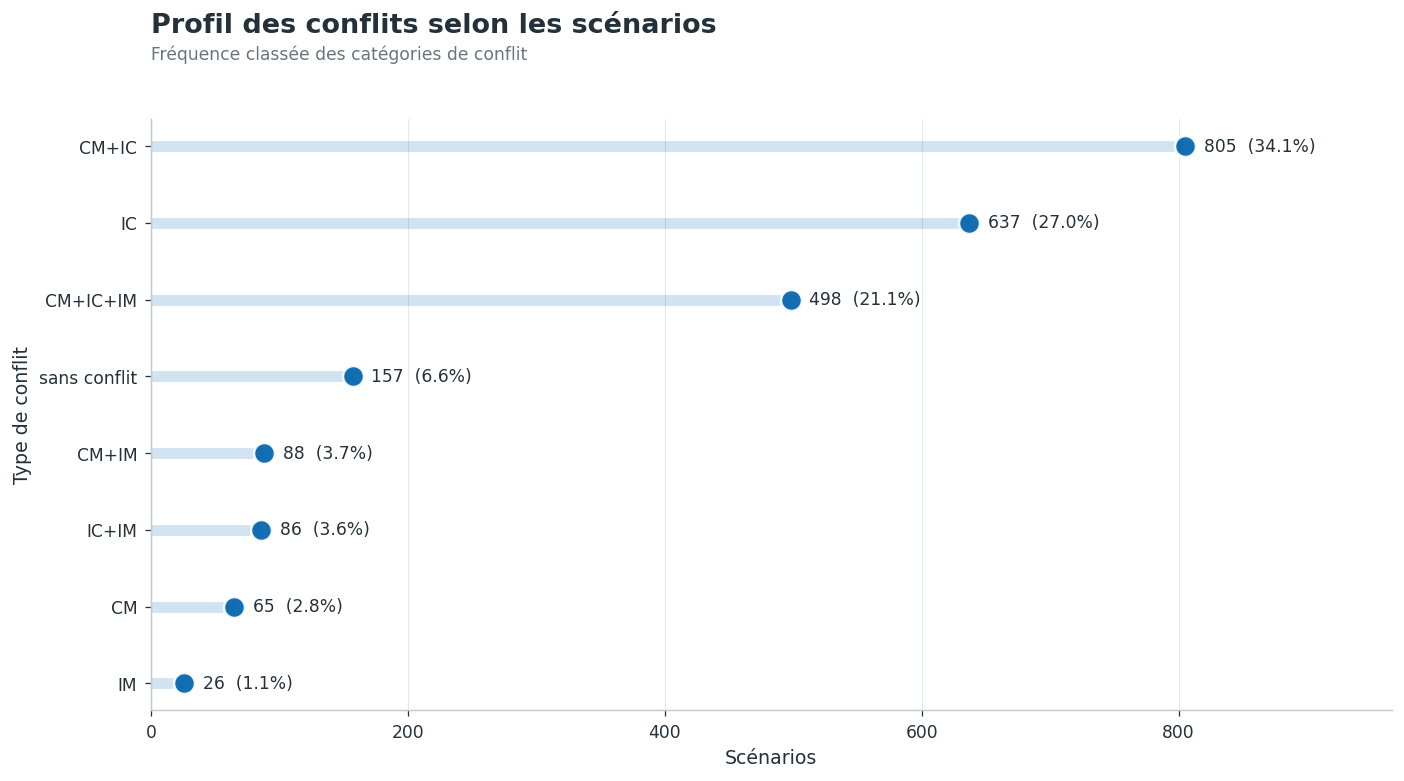

In [31]:
conflict_counts = Counter(normalize_conflict_category(record) for record in scenarios)
conflict_df = pd.DataFrame({
    "type_conflit": list(conflict_counts.keys()),
    "n": list(conflict_counts.values())
}).sort_values("n", ascending=True)

conflict_df["pct"] = 100 * conflict_df["n"] / conflict_df["n"].sum()

fig, ax = plt.subplots(figsize=(11.5, 6.3140))
y = np.arange(len(conflict_df))

ax.hlines(
    y, 0, conflict_df["n"],
    color=BLUE_A, linewidth=6, zorder=1
)
ax.scatter(
    conflict_df["n"], y,
    s=135, color=BLUE, alpha=0.92,
    edgecolor="white", linewidth=1.4, zorder=3
)

offset = max(conflict_df["n"].max(), 1) * 0.018
for yi, n, pct in zip(y, conflict_df["n"], conflict_df["pct"]):
    ax.text(
        n + offset, yi, f"{n}  ({pct:.1f}%)",
        va="center", ha="left",
        fontsize=9.5, color=DARK
    )

ax.set_yticks(y)
ax.set_yticklabels(conflict_df["type_conflit"])
ax.set_xlabel("Scénarios")
ax.set_ylabel("Type de conflit")
ax.set_xlim(0, max(conflict_df["n"].max(), 1) * 1.20)
style_ax(ax, "x")
add_header(
    fig,
    "Profil des conflits selon les scénarios",
    "Fréquence classée des catégories de conflit"
)
fig_conflict_distribution = finish_figure(
    fig, "fig_conflict_distribution.pdf"
)
plt.show()


## 5. Figure 2 — Hiérarchie des stratégies dans le SFT

Un **classement en lollipop chart** permet de comparer les stratégies sans l'effet visuel de gros rectangles.\n\n*Les titres et axes sont volontairement courts afin de rester compatibles avec une mise en page de publication.*

Figure sauvegardée : figures/fig_sft_strategy_distribution.pdf


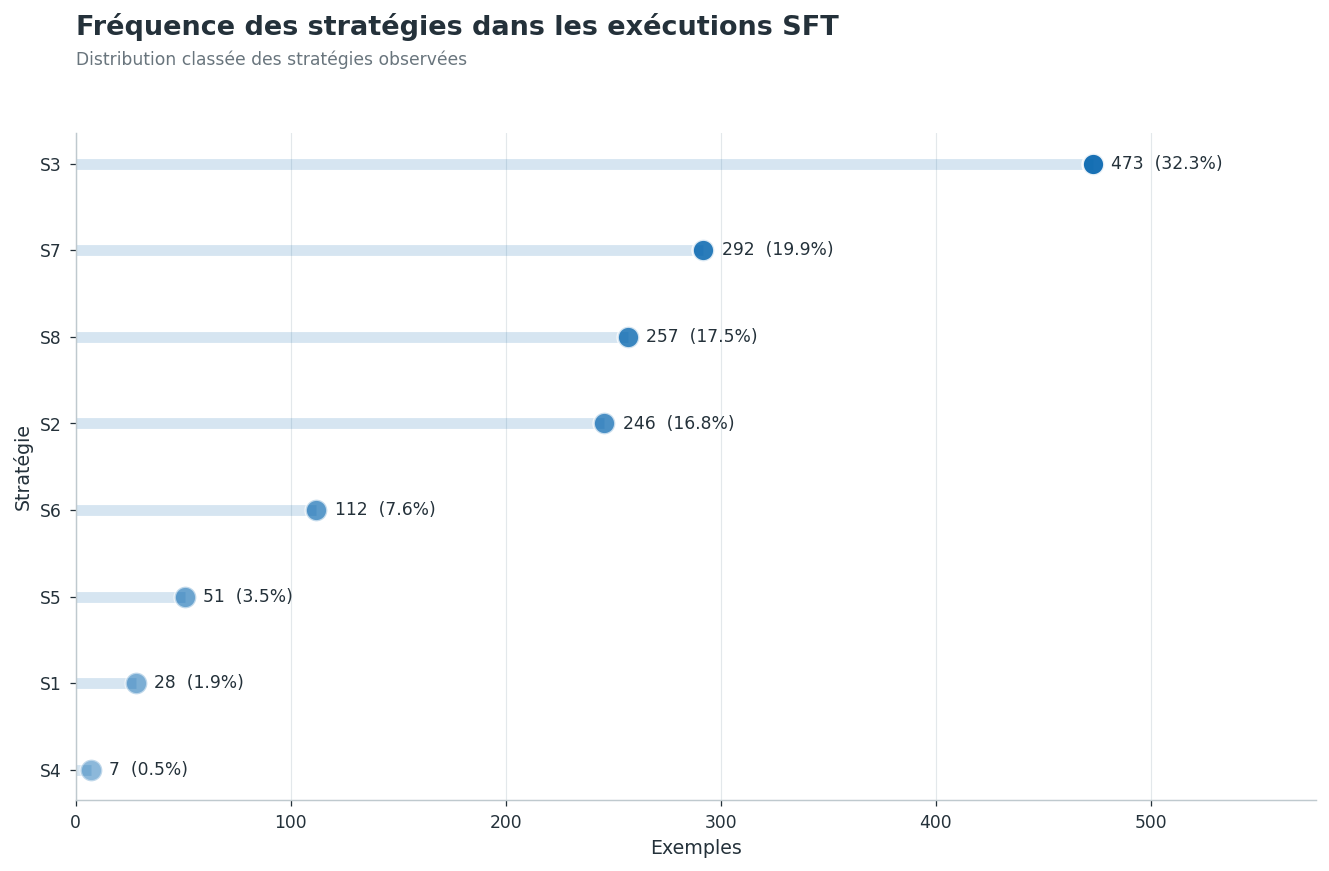

In [32]:
strategy_counts = Counter()
for record in sft_execution_data:
    for strategy in strategy_list(record):
        strategy_counts[strategy] += 1

strategy_df = pd.DataFrame({
    "strategy": STRATEGY_ORDER,
    "n": [strategy_counts.get(strategy, 0) for strategy in STRATEGY_ORDER]
}).sort_values("n", ascending=True)

total_strategy = strategy_df["n"].sum()
strategy_df["pct"] = (
    100 * strategy_df["n"] / total_strategy
    if total_strategy else 0
)

fig, ax = plt.subplots(figsize=(11.5, 7.1253))
y = np.arange(len(strategy_df))

# Alternance légère des variations de transparence pour hiérarchiser
# sans introduire de nouvelles teintes.
alphas = np.linspace(0.45, 0.90, len(strategy_df))

for yi, n, alpha in zip(y, strategy_df["n"], alphas):
    ax.hlines(
        yi, 0, n,
        color=(*tuple(int(BLUE.lstrip("#")[i:i+2], 16)/255 for i in (0,2,4)), 0.16),
        linewidth=6,
        zorder=1
    )
    ax.scatter(
        n, yi, s=145,
        color=BLUE, alpha=float(alpha),
        edgecolor="white", linewidth=1.4,
        zorder=3
    )

offset = max(strategy_df["n"].max(), 1) * 0.018
for yi, n, pct in zip(y, strategy_df["n"], strategy_df["pct"]):
    ax.text(
        n + offset, yi, f"{n}  ({pct:.1f}%)",
        va="center", ha="left",
        fontsize=9.5, color=DARK
    )

ax.set_yticks(y)
ax.set_yticklabels(strategy_df["strategy"])
ax.set_xlabel("Exemples")
ax.set_ylabel("Stratégie")
ax.set_xlim(0, max(strategy_df["n"].max(), 1) * 1.22)
style_ax(ax, "x")
add_header(
    fig,
    "Fréquence des stratégies dans les exécutions SFT",
    "Distribution classée des stratégies observées"
)
fig_sft_strategy_distribution = finish_figure(
    fig, "fig_sft_strategy_distribution.pdf"
)
plt.show()


## 6. Figure 3 — Diversité des stratégies valides par question

Un **dot/bubble plot** met l'accent sur la distribution et utilise la taille des points pour rendre les fréquences plus visibles.\n\n*Les titres et axes sont volontairement courts afin de rester compatibles avec une mise en page de publication.*

Figure sauvegardée : figures/fig_valid_strategies_per_question.pdf


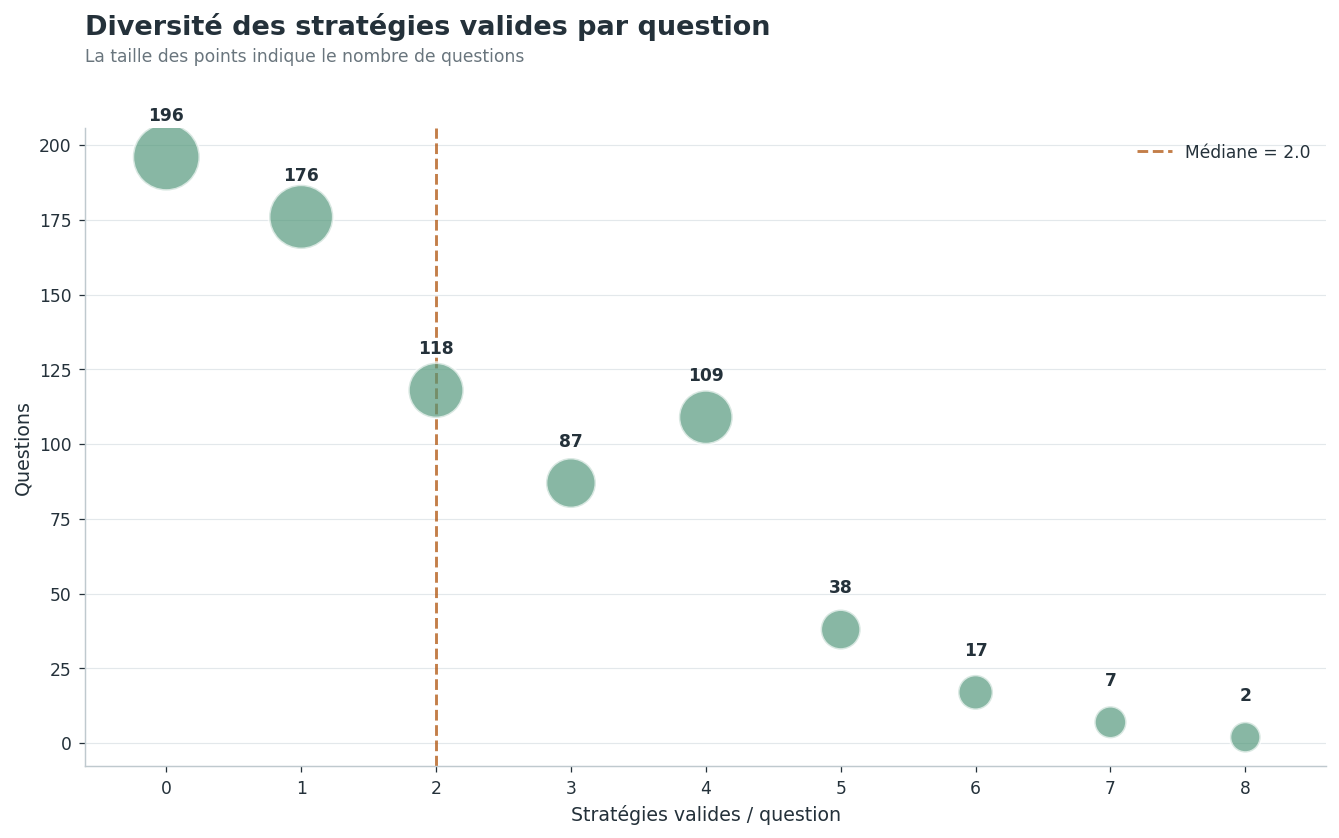

In [33]:
strategies_by_question = defaultdict(set)
for index, record in enumerate(enriched_sft_train):
    qid = scenario_id(record, index)
    strategies_by_question[qid].update(strategy_list(record))

valid_strategy_counts = Counter(
    len(strategies) for strategies in strategies_by_question.values()
)

x_values = np.arange(0, 9)
y_values = np.array([valid_strategy_counts.get(value, 0) for value in x_values])

fig, ax = plt.subplots(figsize=(11.5, 6.8181))

sizes = 280 + 1100 * (y_values / max(y_values.max(), 1))
ax.scatter(
    x_values, y_values,
    s=sizes,
    color=GREEN, alpha=0.68,
    edgecolor="white", linewidth=1.6,
    zorder=3
)

for x, yv in zip(x_values, y_values):
    if yv > 0:
        ax.text(
            x, yv + max(y_values.max(), 1) * 0.055,
            str(int(yv)),
            ha="center", va="bottom",
            fontsize=9.5, fontweight="bold"
        )

median_valid = np.median(
    [len(strategies) for strategies in strategies_by_question.values()]
) if strategies_by_question else 0

ax.axvline(
    median_valid,
    color=BROWN, alpha=0.72,
    linestyle="--", linewidth=1.6,
    label=f"Médiane = {median_valid:.1f}"
)

ax.set_xticks(x_values)
ax.set_xlabel("Stratégies valides / question")
ax.set_ylabel("Questions")
ax.set_xlim(-0.6, 8.6)
style_ax(ax, "y")
ax.legend(frameon=False, loc="upper right")

add_header(
    fig,
    "Diversité des stratégies valides par question",
    "La taille des points indique le nombre de questions"
)
fig_valid_strategies_per_question = finish_figure(
    fig, "fig_valid_strategies_per_question.pdf"
)
plt.show()


## 7. Figure 4 — Composition des splits selon le type de conflit

Une **heatmap annotée** est plus adaptée qu'un empilement de barres lorsque l'objectif est de repérer rapidement les déséquilibres entre splits.\n\n*Les titres et axes sont volontairement courts afin de rester compatibles avec une mise en page de publication.*

Figure sauvegardée : figures/fig_split_distribution.pdf


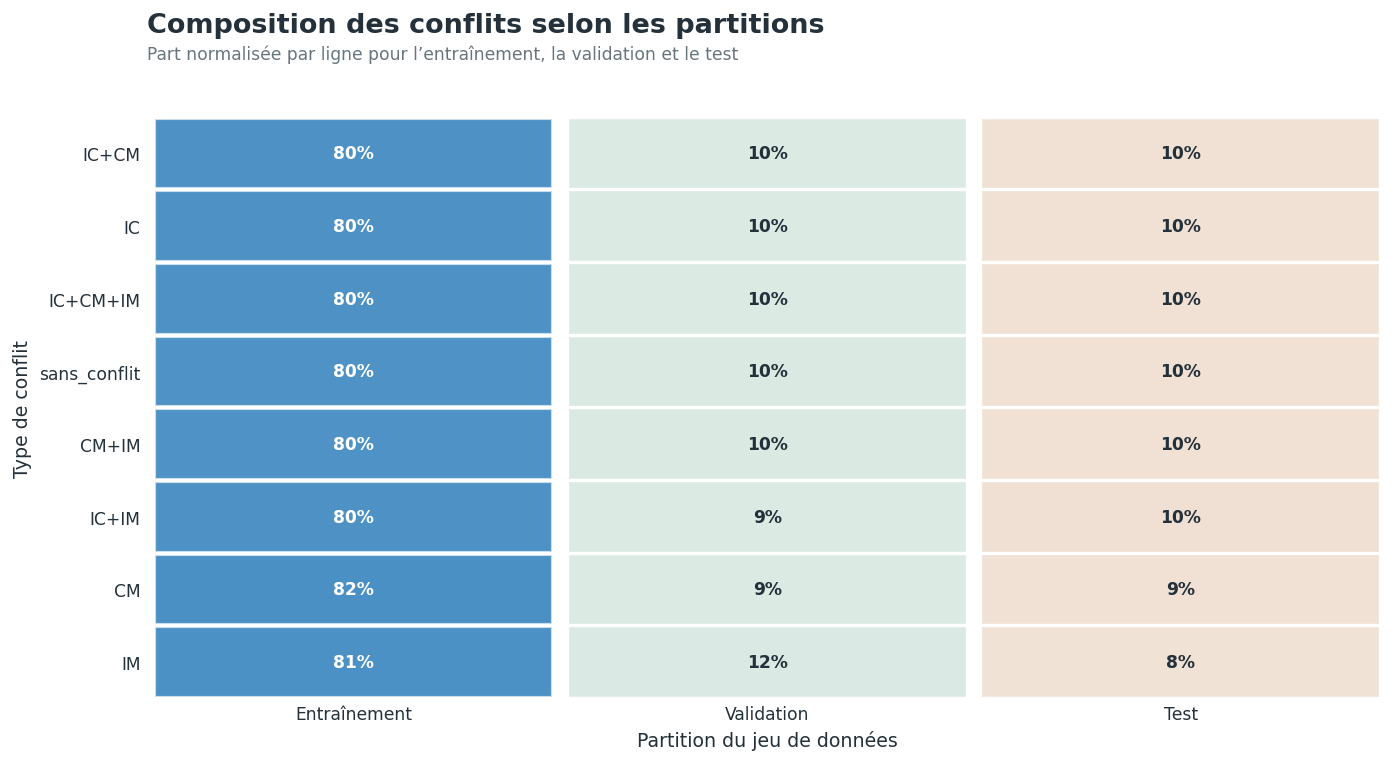

In [34]:
split_records = []
for split_name, records in [
    ("Entraînement", sft_train + grpo_train),
    ("Validation", val_set),
    ("Test", test_set)
]:
    for record in records:
        split_records.append({
            "split": split_name,
            "type_conflit": normalize_conflict_category(record)
        })

split_df = pd.DataFrame(split_records)
split_table = pd.crosstab(
    split_df["type_conflit"], split_df["split"]
)

for column in ["Entraînement", "Validation", "Test"]:
    if column not in split_table.columns:
        split_table[column] = 0

split_table = split_table[["Entraînement", "Validation", "Test"]]
split_table = split_table.loc[
    split_table.sum(axis=1).sort_values(ascending=False).index
]
split_percent = split_table.div(
    split_table.sum(axis=1), axis=0
) * 100

fig, ax = plt.subplots(figsize=(11.5, 6.2103))

# Même famille chromatique : bleu = split principal,
# vert et brun = contrastes, avec transparence.
rgba_map = {
    "Entraînement": BLUE,
    "Validation": GREEN,
    "Test": BROWN,
}
alpha_map = {
    "Entraînement": 0.82,
    "Validation": 0.62,
    "Test": 0.52,
}

# Fond blanc + cellules construites individuellement pour contrôler alpha.
for i, conflict in enumerate(split_percent.index):
    row_values = split_percent.loc[conflict].values
    for j, (split, value) in enumerate(
        zip(split_percent.columns, row_values)
    ):
        ax.add_patch(
            plt.Rectangle(
                (j - 0.48, i - 0.48),
                0.96, 0.96,
                facecolor=rgba_map[split],
                alpha=alpha_map[split] * (0.25 + 0.75 * value / 100),
                edgecolor="white",
                linewidth=1.2
            )
        )
        text_color = "white" if value >= 50 else DARK
        ax.text(
            j, i, f"{value:.0f}%",
            ha="center", va="center",
            fontsize=9.5, fontweight="bold",
            color=text_color
        )

ax.set_xlim(-0.5, len(split_percent.columns) - 0.5)
ax.set_ylim(len(split_percent.index) - 0.5, -0.5)
ax.set_xticks(np.arange(len(split_percent.columns)))
ax.set_xticklabels(split_percent.columns)
ax.set_yticks(np.arange(len(split_percent.index)))
ax.set_yticklabels(split_percent.index)

ax.set_xlabel("Partition du jeu de données")
ax.set_ylabel("Type de conflit")
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

add_header(
    fig,
    "Composition des conflits selon les partitions",
    "Part normalisée par ligne pour l’entraînement, la validation et le test"
)
fig_split_distribution = finish_figure(
    fig, "fig_split_distribution.pdf"
)
plt.show()


## 8. Figure 5 — Distribution du nombre de documents par scénario

Un **violin + jitter + intervalle interquartile** montre à la fois la forme de la distribution, les observations individuelles et la médiane.\n\n*Les titres et axes sont volontairement courts afin de rester compatibles avec une mise en page de publication.*

Figure sauvegardée : figures/fig_documents_per_scenario.pdf


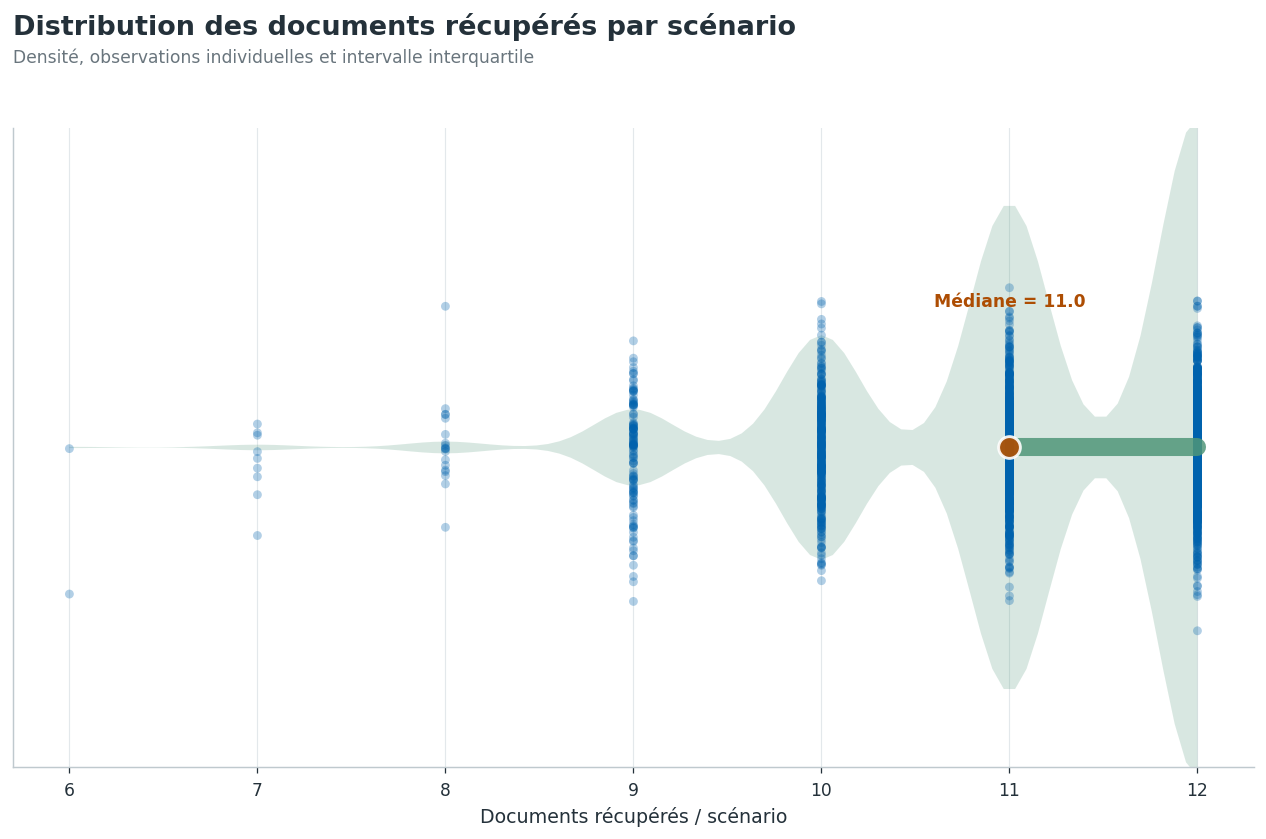

In [35]:
documents_per_scenario = np.array([
    count_retrieved_documents(record) for record in scenarios
], dtype=float)

median_documents = (
    float(np.median(documents_per_scenario))
    if len(documents_per_scenario) else 0.0
)

fig, ax = plt.subplots(figsize=(11.5, 6.8327))

if len(documents_per_scenario):
    parts = ax.violinplot(
        documents_per_scenario,
        positions=[0],
        vert=False,
        showmeans=False,
        showmedians=False,
        showextrema=False,
        widths=0.72
    )

    for body in parts["bodies"]:
        body.set_facecolor(GREEN)
        body.set_edgecolor("none")
        body.set_alpha(0.22)

    rng = np.random.default_rng(42)
    jitter = rng.normal(0, 0.055, size=len(documents_per_scenario))
    ax.scatter(
        documents_per_scenario,
        jitter,
        s=24,
        alpha=0.30,
        color=BLUE,
        edgecolor="none"
    )

    q1, q3 = np.percentile(documents_per_scenario, [25, 75])

    ax.plot(
        [q1, q3], [0, 0],
        color=GREEN, alpha=0.85,
        linewidth=10,
        solid_capstyle="round",
        zorder=4
    )

    ax.scatter(
        [median_documents], [0],
        s=145,
        color=BROWN, alpha=0.90,
        edgecolor="white",
        linewidth=1.6,
        zorder=5
    )

    ax.text(
        median_documents, 0.15,
        f"Médiane = {median_documents:.1f}",
        ha="center", va="bottom",
        fontsize=9.5, fontweight="bold",
        color=BROWN
    )

ax.set_yticks([])
ax.set_xlabel("Documents récupérés / scénario")
ax.set_ylim(-0.35, 0.35)
style_ax(ax, "x")

add_header(
    fig,
    "Distribution des documents récupérés par scénario",
    "Densité, observations individuelles et intervalle interquartile"
)
fig_documents_per_scenario = finish_figure(
    fig, "fig_documents_per_scenario.pdf"
)
plt.show()


## 9. Récapitulatif des fichiers générés

In [36]:
generated_figures = [
    fig_conflict_distribution,
    fig_sft_strategy_distribution,
    fig_valid_strategies_per_question,
    fig_split_distribution,
    fig_documents_per_scenario,
]

print("Figures générées :")
for path in generated_figures:
    print(f"- {path}")

Figures générées :
- figures/fig_conflict_distribution.pdf
- figures/fig_sft_strategy_distribution.pdf
- figures/fig_valid_strategies_per_question.pdf
- figures/fig_split_distribution.pdf
- figures/fig_documents_per_scenario.pdf
